<a href="https://colab.research.google.com/github/chaitanya-077/resume_webpage/blob/main/TB_Analysis_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib seaborn scikit-learn torch torchvision tqdm

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

In [ ]:
ZIP_PATH = "/content/drive/MyDrive/chest-xray-dataset.zip"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

EXTRACT_PATH = "/content/chest_xray"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extracted!")

Extracted!


In [ ]:
os.listdir(EXTRACT_PATH)

['data.yaml', 'test', 'train', 'val']

In [ ]:
DATASET_PATH = "/content/chest_xray"
print(os.listdir(DATASET_PATH))

['data.yaml', 'test', 'train', 'val']


In [ ]:
print(os.listdir(DATASET_PATH))

['data.yaml', 'test', 'train', 'val']


In [ ]:
BASE_PATH = "/content/chest_xray"   # your extracted folder

TRAIN_PATH = BASE_PATH + "/train"
VAL_PATH   = BASE_PATH + "/val"
TEST_PATH  = BASE_PATH + "/test"

In [ ]:
import os

print("Train:", os.listdir(TRAIN_PATH))
print("Val:", os.listdir(VAL_PATH))
print("Test:", os.listdir(TEST_PATH))

Train: ['normal', 'tuberculosis', 'pneumonia']
Val: ['normal', 'tuberculosis', 'pneumonia']
Test: ['normal', 'tuberculosis', 'pneumonia']


In [ ]:
for folder in os.listdir(TRAIN_PATH):
    print(folder)

normal
tuberculosis
pneumonia


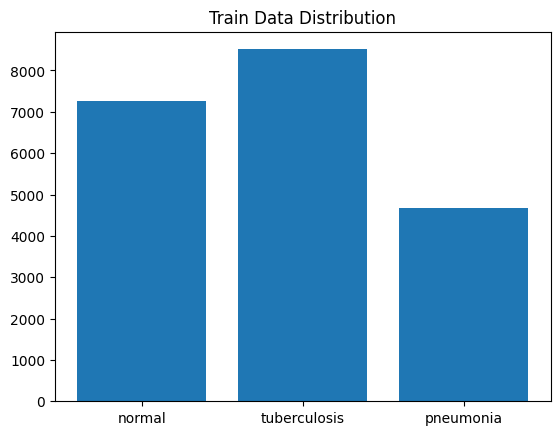

In [ ]:
classes = os.listdir(TRAIN_PATH)

counts = {}
for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(TRAIN_PATH, cls)))

import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values())
plt.title("Train Data Distribution")
plt.show()

In [ ]:
from torch.utils.data import Dataset
import cv2, numpy as np, torch, os

class ChestDataset(Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []

        self.classes = sorted(os.listdir(root))  # sorted → deterministic class→label mapping
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root, c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder, f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]

        img = cv2.imread(img_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        clahe = cv2.createCLAHE(2.0,(8,8)).apply(
            cv2.resize(gray, (224,224))
        )

        img = clahe / 255.0
        img = np.stack([img]*3)

        return torch.tensor(img, dtype=torch.float32), self.labels[idx]

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(ChestDataset(TRAIN_PATH), batch_size=32, shuffle=True)
val_loader   = DataLoader(ChestDataset(VAL_PATH), batch_size=32)
test_loader  = DataLoader(ChestDataset(TEST_PATH), batch_size=32)

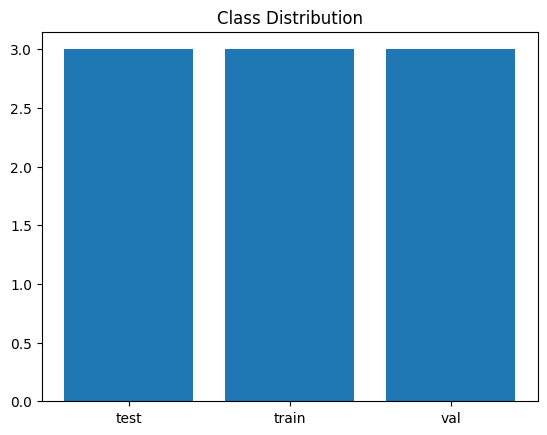

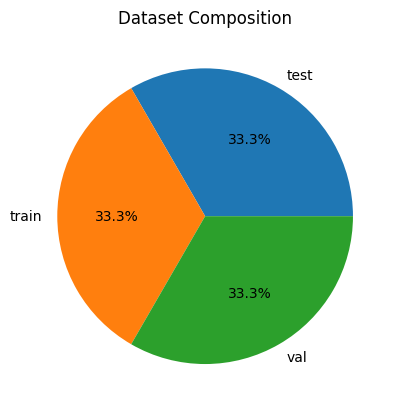

In [ ]:
classes = os.listdir(DATASET_PATH)

counts = {}
for cls in classes:
    full_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(full_path): # Only process if it's a directory
        counts[cls] = len(os.listdir(full_path))

# Bar chart
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.show()

# Pie chart
plt.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%')
plt.title("Dataset Composition")
plt.show()

In [ ]:
IMG_SIZE = 224

def resize_maxpool(img):
    img = cv2.resize(img, (IMG_SIZE*2, IMG_SIZE*2))
    return img.reshape(IMG_SIZE,2,IMG_SIZE,2).max(axis=(1,3))

def apply_clahe(img):
    return cv2.createCLAHE(2.0,(8,8)).apply(img)

def preprocess_all(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilinear = cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    maxpool = resize_maxpool(gray)

    clahe = apply_clahe(bilinear)
    normalized = clahe / 255.0

    edges = cv2.Canny(clahe, 50, 150)

    return {
        "original": img,
        "gray": gray,
        "bilinear": bilinear,
        "maxpool": maxpool,
        "clahe": clahe,
        "normalized": normalized,
        "edges": edges
    }


In [ ]:
def visualize_pipeline(data, title=""):
    keys = list(data.keys())

    plt.figure(figsize=(12,8))
    for i,k in enumerate(keys):
        plt.subplot(2,4,i+1)
        plt.imshow(data[k], cmap='gray')
        plt.title(k)
        plt.axis("off")

    plt.suptitle(f"Preprocessing Pipeline - {title}")
    plt.show()

In [ ]:
def difference_maps(data):
    d1 = cv2.absdiff(data["gray"][:224,:224], data["bilinear"])
    d2 = cv2.absdiff(data["bilinear"], data["maxpool"])
    d3 = cv2.absdiff(data["bilinear"], data["clahe"])

    titles = ["Gray→Bilinear","Bilinear→MaxPool","Bilinear→CLAHE"]

    plt.figure(figsize=(12,4))
    for i,d in enumerate([d1,d2,d3]):
        plt.subplot(1,3,i+1)
        plt.imshow(d, cmap='hot')
        plt.title(titles[i])
        plt.colorbar()

    plt.suptitle("Information Retention Maps")
    plt.show()

In [ ]:
def edge_analysis(data):
    e1 = cv2.Canny(data["gray"],50,150)
    e2 = data["edges"]

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(e1, cmap='gray')
    plt.title("Original Edges")

    plt.subplot(1,2,2)
    plt.imshow(e2, cmap='gray')
    plt.title("CLAHE Edges")

    plt.show()

In [ ]:
def histogram_analysis(data):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.hist(data["gray"].ravel(), bins=256)
    plt.title("Gray Histogram")

    plt.subplot(1,2,2)
    plt.hist(data["clahe"].ravel(), bins=256)
    plt.title("CLAHE Histogram")

    plt.show()

In [ ]:
from PIL import Image
augment = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2)
])

def show_augmentation(path):
    # Use cv2 to load and convert to RGB, then to PIL Image
    img_cv2 = cv2.imread(path)
    if img_cv2 is None:
        raise ValueError(f"Broken image or not found: {path}")
    img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(img_cv2_rgb)

    plt.figure(figsize=(10,4))
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(augment(img))
        plt.axis("off")

    plt.suptitle("Augmentation Examples")
    plt.show()

In [ ]:
def get_sample_per_class(dataset):
    samples = {}

    for path, label in zip(dataset.paths, dataset.labels):
        class_name = dataset.classes[label]

        if class_name not in samples:
            samples[class_name] = path

        if len(samples) == len(dataset.classes):
            break

    return samples

samples = get_sample_per_class(train_loader.dataset)

print("Selected samples:")
for k,v in samples.items():
    print(k, "->", v)

Selected samples:
normal -> /content/chest_xray/train/normal/normal-2552.jpg
pneumonia -> /content/chest_xray/train/pneumonia/pneumonia-777.jpg
tuberculosis -> /content/chest_xray/train/tuberculosis/tuberculosis-1459.jpg



========== CLASS: normal ==========



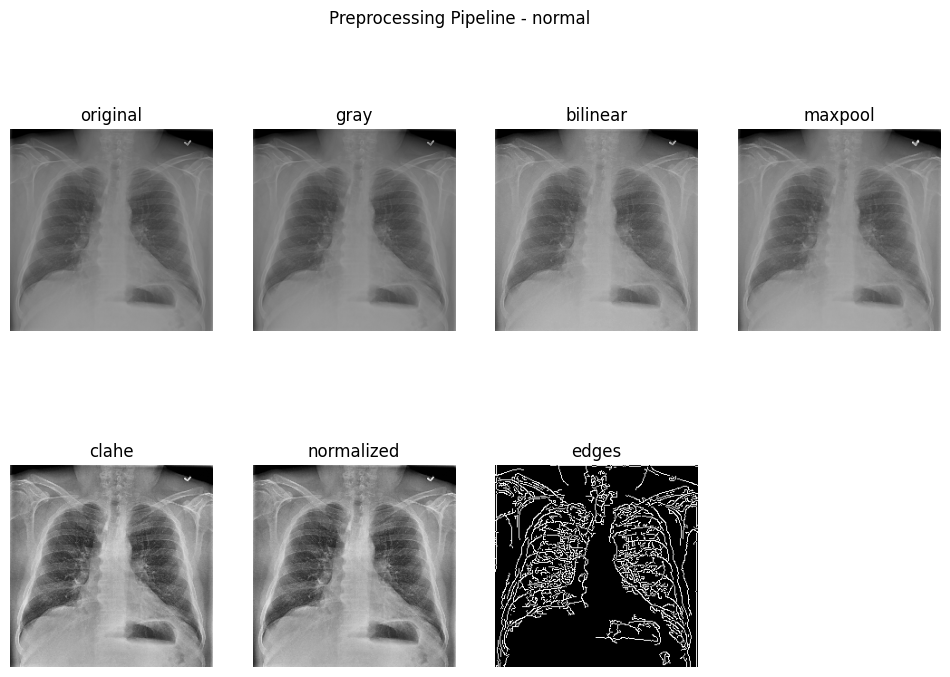

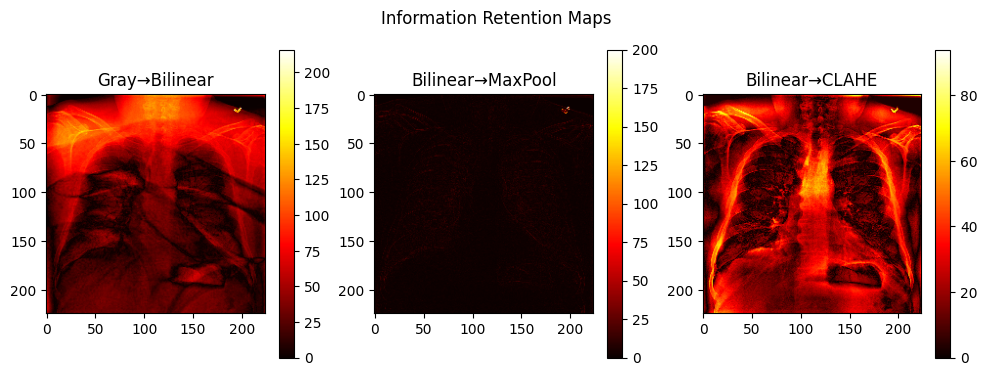

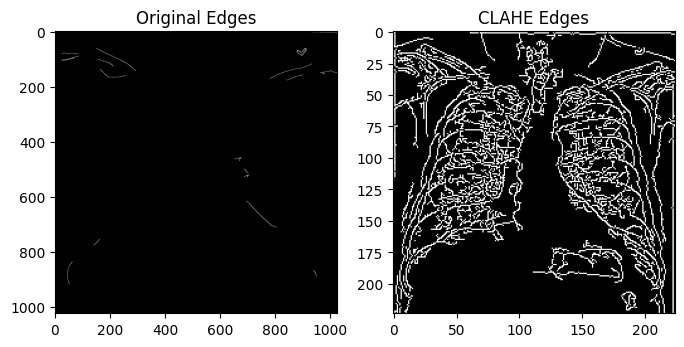

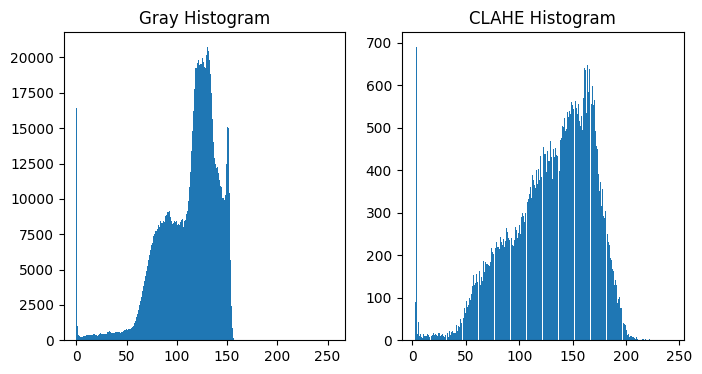

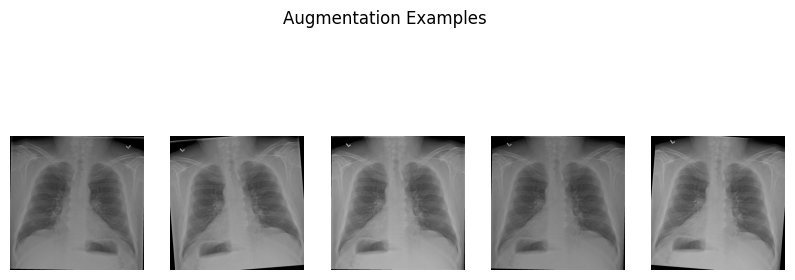

Skipping detailed visualization for pneumonia to prevent output truncation.
Skipping detailed visualization for tuberculosis to prevent output truncation.


In [ ]:
for class_name, path in samples.items():
    # Temporarily limit plotting to only one visualization for one class
    if class_name == 'normal':
        print(f"\n========== CLASS: {class_name} ==========\n")

        data = preprocess_all(path)

        visualize_pipeline(data, class_name)
        # difference_maps(data)
        # edge_analysis(data)
        # histogram_analysis(data)
        # show_augmentation(path)
    else:
        print(f"Skipping detailed visualization for {class_name} to prevent output truncation.")

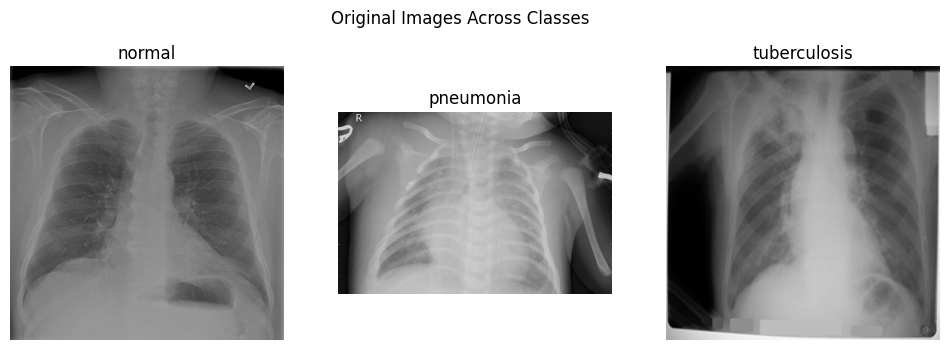

In [ ]:
plt.figure(figsize=(12,4))

for i, (cls, path) in enumerate(samples.items()):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    plt.subplot(1,3,i+1)
    plt.imshow(gray, cmap='gray')
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Original Images Across Classes")
plt.show()

In [ ]:
class ChestDataset(Dataset):
    def __init__(self, root):
        self.paths, self.labels = [], []
        self.classes = sorted(os.listdir(root))  # sorted → deterministic class→label mapping
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        data = preprocess_all(self.paths[idx])

        img = data["normalized"]
        img = np.stack([img]*3)

        return torch.tensor(img, dtype=torch.float32), self.labels[idx]

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 113MB/s]
/tmp/ipykernel_941/418808217.py:51: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



===== Epoch 1/3 =====


Training:   0%|          | 0/320 [00:00<?, ?it/s]/tmp/ipykernel_941/418808217.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training: 100%|██████████| 320/320 [06:39<00:00,  1.25s/it, loss=0.318]


Train Loss: 0.4832
Validation Loss: 0.3984

===== Epoch 2/3 =====


Training: 100%|██████████| 320/320 [06:18<00:00,  1.18s/it, loss=0.336]


Train Loss: 0.4045
Validation Loss: 0.3883

===== Epoch 3/3 =====


Training: 100%|██████████| 320/320 [06:11<00:00,  1.16s/it, loss=0.345]


Train Loss: 0.3948
Validation Loss: 0.3862


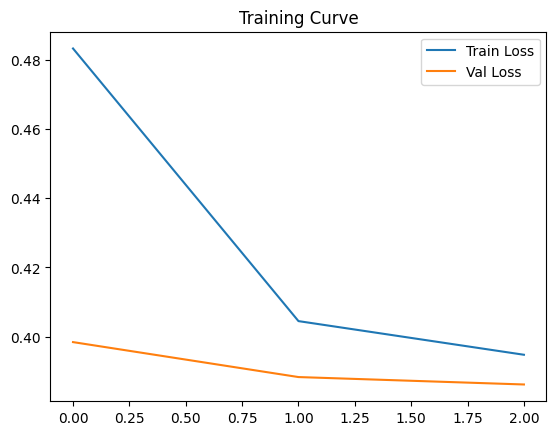

In [ ]:
# ================================
# 🚀 IMPORTS
# ================================
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# ================================
# ⚡ DEVICE
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================
# 📦 DATA LOADERS (BIGGER BATCH)
# ================================
train_loader = DataLoader(ChestDataset(TRAIN_PATH), batch_size=64, shuffle=True)
val_loader   = DataLoader(ChestDataset(VAL_PATH), batch_size=64)

# ================================
# 🤖 MODEL (LIGHTWEIGHT)
# ================================
model = models.mobilenet_v2(pretrained=True)

# Freeze most layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)

model = model.to(device)

# ================================
# ⚙️ LOSS + OPTIMIZER
# ================================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

# ================================
# ⚡ MIXED PRECISION (FAST!)
# ================================
scaler = torch.cuda.amp.GradScaler()

# ================================
# 📈 TRAINING LOOP (FAST)
# ================================
EPOCHS = 3

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    running_loss = 0

    loop = tqdm(train_loader, desc="Training")

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    # 🔹 VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Validation Loss: {avg_val_loss:.4f}")

# ================================
# 📊 TRAINING CURVE
# ================================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()

In [ ]:
from tqdm import tqdm

def preprocess_dataset(dataset):
    processed = []

    print("Preprocessing dataset (one-time)...")

    for path, label in tqdm(zip(dataset.paths, dataset.labels), total=len(dataset.paths)):
        data = preprocess_all(path)

        img = data["normalized"]
        img = np.stack([img]*3)

        processed.append((img, label))

    return processed

In [ ]:
import os

SAVE_PATH = "/content/processed_dataset"

for split in ["train", "val", "test"]: # Add "test" to ensure directory creation
    for cls in os.listdir(BASE_PATH + "/" + split):
        os.makedirs(f"{SAVE_PATH}/{split}/{cls}", exist_ok=True)

In [ ]:
from tqdm import tqdm
import cv2

IMG_SIZE = 224

def process_and_save(input_path, output_path):
    img = cv2.imread(input_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    resized = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    clahe = cv2.createCLAHE(2.0,(8,8)).apply(resized)

    cv2.imwrite(output_path, clahe)

In [ ]:
for split in ["train", "val", "test"]: # Add "test" to the splits to preprocess
    print(f"\nProcessing {split}...")

    for cls in os.listdir(BASE_PATH + "/" + split):
        input_dir = f"{BASE_PATH}/{split}/{cls}"
        output_dir = f"{SAVE_PATH}/{split}/{cls}"

        os.makedirs(output_dir, exist_ok=True) # Ensure output directory exists

        for img_name in tqdm(os.listdir(input_dir)):
            in_path = os.path.join(input_dir, img_name)
            out_path = os.path.join(output_dir, img_name)

            process_and_save(in_path, out_path)


Processing train...


100%|██████████| 4674/4674 [01:35<00:00, 49.03it/s]



Processing val...


100%|██████████| 570/570 [00:10<00:00, 52.91it/s]



Processing test...


100%|██████████| 580/580 [00:12<00:00, 47.69it/s]


In [ ]:
class DiskDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))  # sorted → deterministic class→label mapping
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)

        img = img / 255.0
        img = np.stack([img]*3)

        return torch.tensor(img, dtype=torch.float32), self.labels[idx]

In [ ]:
train_loader = DataLoader(DiskDataset(SAVE_PATH + "/train"), batch_size=64, shuffle=True, num_workers=2)
val_loader   = DataLoader(DiskDataset(SAVE_PATH + "/val"), batch_size=64, num_workers=2)

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

EPOCHS = 5

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    total_loss = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Train Loss:", total_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            val_loss += criterion(model(x),y).item()

    print("Val Loss:", val_loss)


===== Epoch 1/5 =====
Train Loss: 156.11547157168388
Val Loss: 16.29556068778038

===== Epoch 2/5 =====
Train Loss: 130.06270039081573
Val Loss: 15.690943792462349

===== Epoch 3/5 =====
Train Loss: 125.08274987339973
Val Loss: 14.746345460414886

===== Epoch 4/5 =====
Train Loss: 123.6447129547596
Val Loss: 15.008561462163925

===== Epoch 5/5 =====
Train Loss: 122.06674276292324
Val Loss: 14.655702948570251


In [ ]:
for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    total_loss = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ✅ FIX HERE
    avg_train_loss = total_loss / len(train_loader)
    print("Train Loss:", avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            val_loss += criterion(model(x),y).item()

    # ✅ FIX HERE
    avg_val_loss = val_loss / len(val_loader)
    print("Val Loss:", avg_val_loss)


===== Epoch 1/5 =====
Train Loss: 0.37600941038690505
Val Loss: 0.37980740778148175

===== Epoch 2/5 =====
Train Loss: 0.37546680136583743
Val Loss: 0.3593399427831173

===== Epoch 3/5 =====
Train Loss: 0.37095873123034834
Val Loss: 0.3598723214119673

===== Epoch 4/5 =====
Train Loss: 0.3674604967236519
Val Loss: 0.35672692246735094

===== Epoch 5/5 =====
Train Loss: 0.36714640581049024
Val Loss: 0.35605791211128235


In [ ]:
print("Example loss:", loss.item())

Example loss: 0.41347765922546387


In [ ]:
# Unfreeze last block
for param in model.features[-1].parameters():
    param.requires_grad = True

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

In [ ]:
# ================================
# ⚙️ LOSS + OPTIMIZER (UPDATED)
# ================================
criterion = nn.CrossEntropyLoss()

# 🔥 Lower LR for fine-tuning
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

# ================================
# 📈 TRAINING LOOP (FINE-TUNING)
# ================================
EPOCHS = 5

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # 🔹 TRAIN
    model.train()
    running_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    # 🔹 VALIDATION
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Validation Loss: {avg_val_loss:.4f}")


===== Epoch 1/5 =====
Train Loss: 0.3572
Validation Loss: 0.3542

===== Epoch 2/5 =====
Train Loss: 0.3540
Validation Loss: 0.3538

===== Epoch 3/5 =====
Train Loss: 0.3526
Validation Loss: 0.3542

===== Epoch 4/5 =====
Train Loss: 0.3512
Validation Loss: 0.3527

===== Epoch 5/5 =====
Train Loss: 0.3496
Validation Loss: 0.3548


In [ ]:
def __getitem__(self, idx):
    img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (224,224))   # ensure consistent size
    img = img.astype(np.float32) / 255.0

    img = np.stack([img, img, img], axis=0)  # (3, H, W)

    # 🔥 CRITICAL FIX
    img = np.ascontiguousarray(img)

    return torch.from_numpy(img), self.labels[idx]

In [ ]:
class DiskDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))  # 🔥 sorted for consistency
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)

        # 🔥 SAFETY CHECK
        if img is None:
            raise ValueError(f"Image not found: {self.paths[idx]}")

        img = cv2.resize(img, (224,224))
        img = img.astype(np.float32) / 255.0

        # 🔥 MAKE SHAPE (3,224,224)
        img = np.stack([img, img, img], axis=0)

        # 🔥 FORCE CONTIGUOUS MEMORY
        img = np.ascontiguousarray(img)

        # 🔥 IMPORTANT: USE from_numpy (NOT torch.tensor)
        img = torch.from_numpy(img)

        return img, self.labels[idx]

In [ ]:
test_loader = DataLoader(
    DiskDataset(BASE_PATH + "/test"),
    batch_size=32,   # reduce batch size slightly
    shuffle=False,
    num_workers=0    # 🔥 MUST BE ZERO
)

In [ ]:
x, y = next(iter(test_loader))
print(x.shape)

torch.Size([32, 3, 224, 224])


              precision    recall  f1-score   support

           0       0.67      0.69      0.68       925
           1       0.79      0.96      0.87       580
           2       0.84      0.72      0.77      1064

    accuracy                           0.76      2569
   macro avg       0.77      0.79      0.77      2569
weighted avg       0.77      0.76      0.76      2569



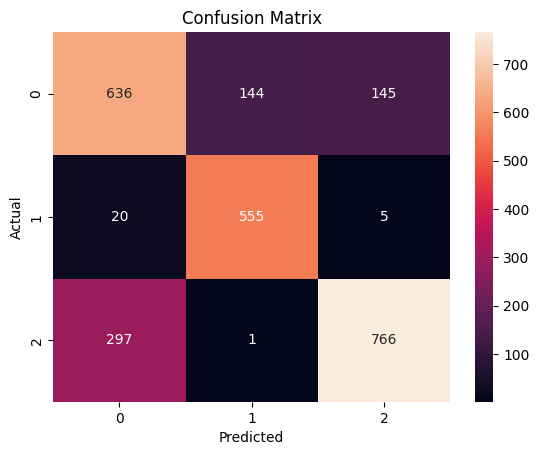

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)

        out = model(x)
        preds = torch.argmax(out,1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

# 📄 Classification Report
print(classification_report(y_true, y_pred))

# 📊 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda
Class weights: tensor([0.2935, 0.4561, 0.2504])

===== Epoch 1/3 =====


Training: 100%|██████████| 640/640 [00:40<00:00, 15.72it/s, loss=0.713]


Train Loss: 0.6476
Validation Loss: 0.4712

===== Epoch 2/3 =====


Training: 100%|██████████| 640/640 [00:40<00:00, 15.74it/s, loss=0.37]


Train Loss: 0.4337
Validation Loss: 0.4226

===== Epoch 3/3 =====


Training: 100%|██████████| 640/640 [00:40<00:00, 15.81it/s, loss=3]


Train Loss: 0.4071
Validation Loss: 0.3981


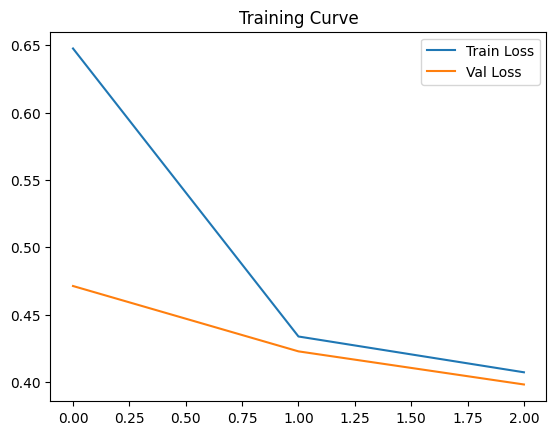

In [ ]:
# ================================
# 🚀 IMPORTS
# ================================
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# ================================
# ⚡ DEVICE
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================
# 📦 DATA LOADERS
# ================================
train_dataset = DiskDataset(SAVE_PATH + "/train")
val_dataset   = DiskDataset(SAVE_PATH + "/val")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=32, num_workers=0)

# ================================
# 🔥 CLASS WEIGHTS (CRITICAL FIX)
# ================================
class_counts = []

for cls in train_dataset.classes:
    class_counts.append(len(os.listdir(os.path.join(SAVE_PATH + "/train", cls))))

class_counts = torch.tensor(class_counts, dtype=torch.float32)

weights = 1.0 / class_counts
weights = weights / weights.sum()

print("Class weights:", weights)

# ================================
# 🤖 MODEL (IMPROVED FINE-TUNING)
# ================================
model = models.mobilenet_v2(pretrained=True)

# Freeze all
for param in model.parameters():
    param.requires_grad = False

# 🔥 Unfreeze last TWO blocks (important)
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Better classifier
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)

model = model.to(device)

# ================================
# ⚙️ LOSS + OPTIMIZER
# ================================
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5   # 🔥 low LR for fine-tuning
)

# ================================
# 📈 TRAINING LOOP (FIXED)
# ================================
EPOCHS = 3

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # 🔹 TRAIN
    model.train()
    running_loss = 0

    loop = tqdm(train_loader, desc="Training")

    for x, y in loop:
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    # 🔹 VALIDATION
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Validation Loss: {avg_val_loss:.4f}")

# ================================
# 📊 TRAINING CURVE
# ================================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()


===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0     0.7990    0.3308    0.4679       925
           1     0.8021    0.9293    0.8610       580
           2     0.6731    0.9577    0.7905      1064

    accuracy                         0.7256      2569
   macro avg     0.7580    0.7393    0.7065      2569
weighted avg     0.7475    0.7256    0.6903      2569


Overall Accuracy: 0.7256


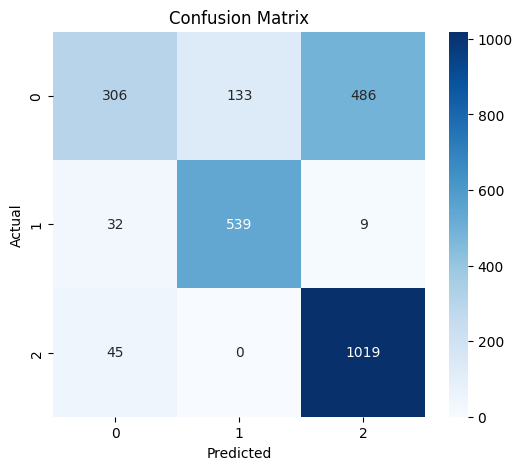

In [ ]:
# ================================
# 📊 IMPORTS
# ================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# ================================
# 🚀 EVALUATION FUNCTION
# ================================
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

# ================================
# 📈 METRICS
# ================================
print("\n===== CLASSIFICATION REPORT =====\n")
print(classification_report(y_true, y_pred, digits=4))

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {acc:.4f}")

# ================================
# 📊 CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Total Misclassified: 705


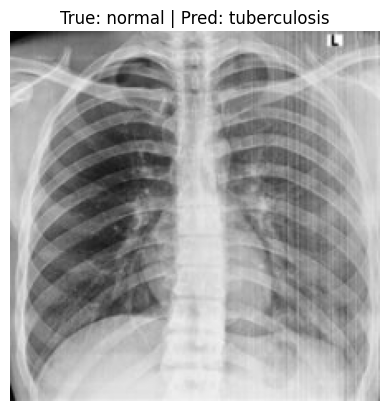

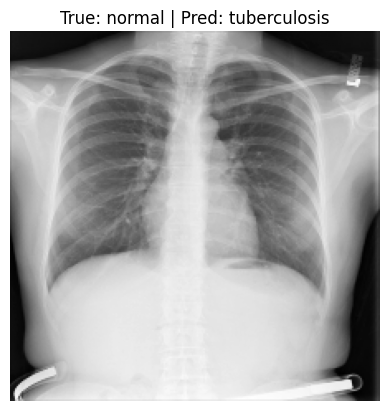

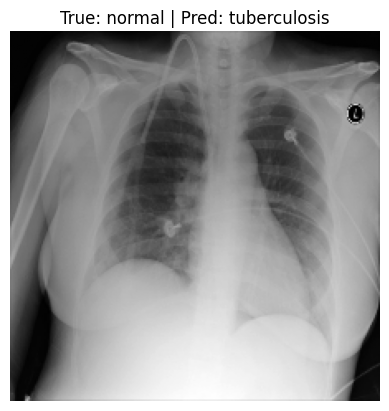

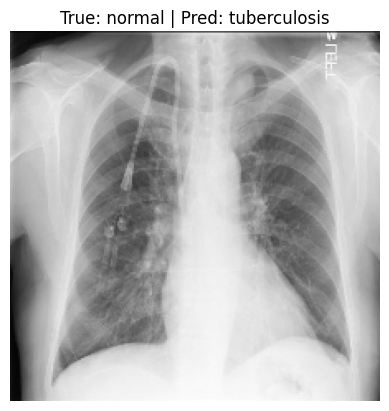

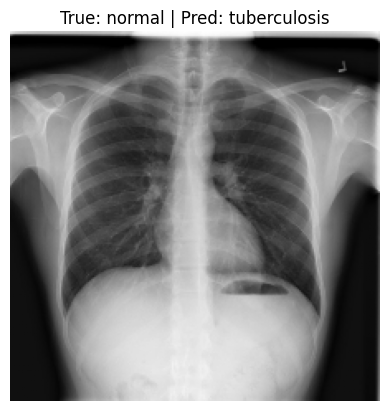

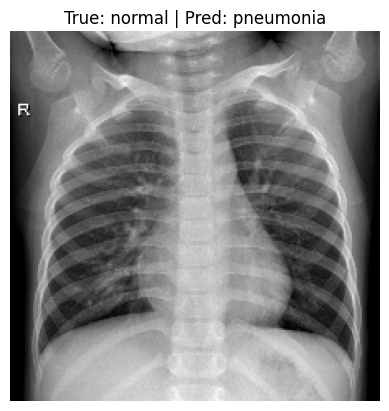

In [ ]:
# ================================
# 🔍 MISCLASSIFICATION
# ================================
misclassified = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]

print("Total Misclassified:", len(misclassified))


# Show some examples
def show_misclassified(loader, indices, max_show=6):
    count = 0
    shown = 0

    for x, y in loader:
        for i in range(len(x)):
            if count in indices:
                plt.imshow(x[i][0].numpy(), cmap='gray')
                plt.title(f"True: {loader.dataset.classes[y[i]]} | Pred: {loader.dataset.classes[y_pred[count]]}")
                plt.axis("off")
                plt.show()

                shown += 1
                if shown >= max_show:
                    return
            count += 1

show_misclassified(test_loader, misclassified)

In [ ]:
# ================================
# 🔥 GRAD-CAM  (MobileNetV2)
# ================================
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.grad = None
        self.act  = None

        def forward_hook(module, input, output):
            self.act = output

        # ✅ FIX: register_full_backward_hook (replaces deprecated register_backward_hook)
        def backward_hook(module, grad_in, grad_out):
            self.grad = grad_out[0]

        model.features[-1].register_forward_hook(forward_hook)
        model.features[-1].register_full_backward_hook(backward_hook)

    def generate(self, x):
        self.model.eval()
        out = self.model(x)
        pred = out.argmax()

        self.model.zero_grad()
        out[0, pred].backward()

        weights = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.act).sum(dim=1)

        cam = cam.squeeze().cpu().detach().numpy()

        # ✅ FIX: ReLU first – discard negative contributions
        cam = np.maximum(cam, 0)

        # Normalize to [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Smooth for cleaner overlay
        cam = cv2.GaussianBlur(cam, (5, 5), 0)

        return cam


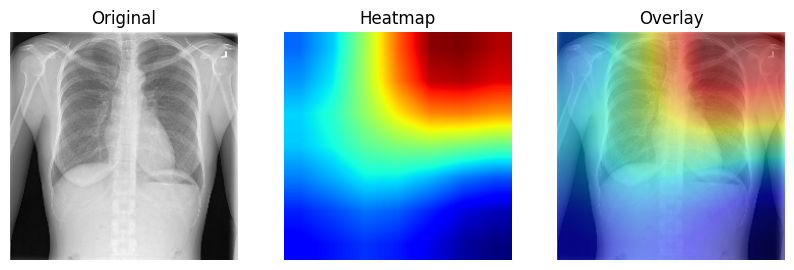

In [ ]:
# ================================
# 🎯 VISUALIZE GRAD-CAM
# ================================
import cv2

cam = GradCAM(model)

x, y = next(iter(test_loader))
sample = x[0].unsqueeze(0).to(device)

heatmap = cam.generate(sample)

# Original image
img = x[0][0].numpy()

# Resize heatmap
heatmap_resized = cv2.resize(heatmap, (224,224))

# Overlay
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap_resized, cmap='jet')
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img, cmap='gray')
plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()

In [ ]:
# ================================
# 🫁 LUNG VALIDATION
# ================================
def segment_lung(img):
    _, mask = cv2.threshold((img*255).astype(np.uint8), 50, 255, cv2.THRESH_BINARY)
    return mask

def validate_cam(cam, mask):
    cam_bin = cam > 0.5
    mask_bin = mask > 0

    overlap = np.sum(cam_bin & mask_bin)
    total = np.sum(cam_bin) + 1e-5

    return overlap / total


mask = segment_lung(img)
score = validate_cam(heatmap_resized, mask)

print("Lung Overlap Score:", score)

Lung Overlap Score: 0.9955287882146832


In [ ]:
# ================================
# ⚠️ CONFIDENCE SYSTEM
# ================================
def predict(image, threshold=0.7):
    model.eval()

    with torch.no_grad():
        out = model(image.unsqueeze(0).to(device))
        prob = torch.softmax(out, dim=1)

        conf, pred = prob.max(1)

        if conf.item() < threshold:
            return "REVIEW", conf.item()

        return test_loader.dataset.classes[pred.item()], conf.item()


pred, conf = predict(x[0])
print("Prediction:", pred, "| Confidence:", conf)

Prediction: normal | Confidence: 0.7036580443382263


In [ ]:
# ================================
# 🧠 FEATURE EXTRACTION
# ================================
def extract_features(loader):
    feats, labels = [], []

    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            f = model.features(x)
            f = f.mean([2,3])  # global pooling

            feats.append(f.cpu().numpy())
            labels.extend(y.numpy())

    return np.vstack(feats), np.array(labels)

features, labels = extract_features(train_loader)

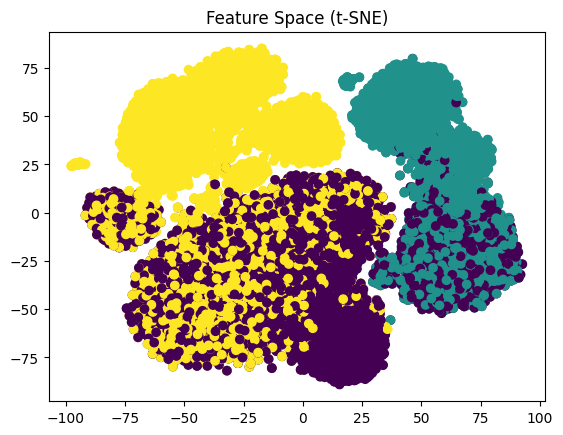

In [ ]:
# ================================
# 📉 FEATURE VISUALIZATION
# ================================
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
f_pca = pca.fit_transform(features)

tsne = TSNE(n_components=2)
f_tsne = tsne.fit_transform(f_pca)

plt.scatter(f_tsne[:,0], f_tsne[:,1], c=labels)
plt.title("Feature Space (t-SNE)")
plt.show()

In [ ]:
# ================================
# 🔗 CLUSTERING
# ================================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(features)

score = adjusted_rand_score(labels, clusters)
print("Cluster Alignment Score:", score)

Cluster Alignment Score: 0.44990485303885847


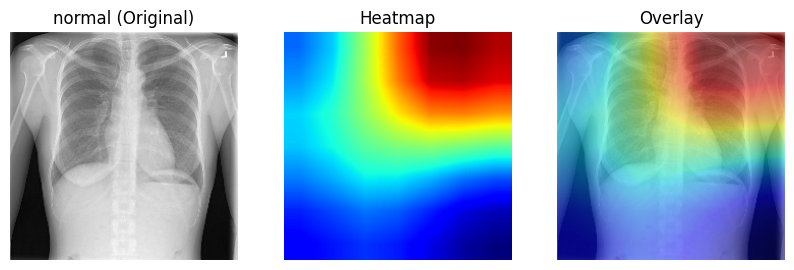

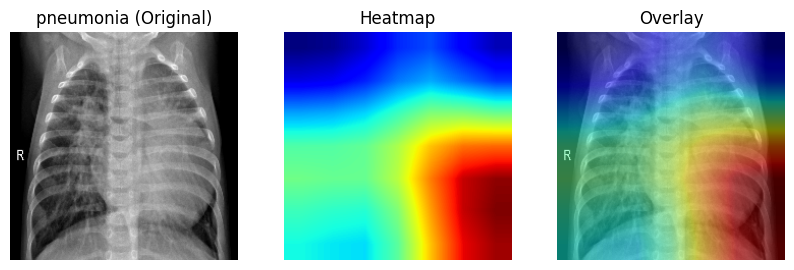

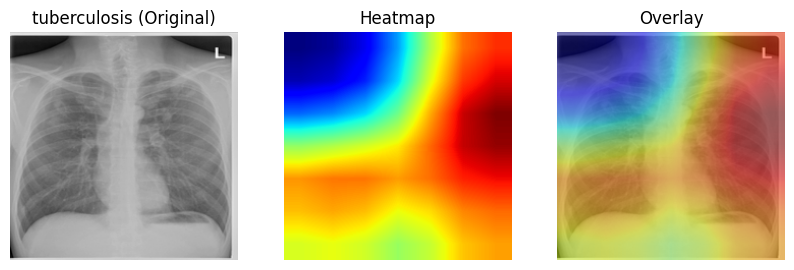

In [ ]:
# ================================
# 🎯 MULTI-CLASS GRAD-CAM VISUALIZATION
# ================================
def show_gradcam_for_each_class(loader):
    cam = GradCAM(model)
    shown = {0: False, 1: False, 2: False}

    class_names = loader.dataset.classes

    for x, y in loader:
        for i in range(len(x)):
            label = y[i].item()

            if not shown[label]:
                sample = x[i].unsqueeze(0).to(device)
                heatmap = cam.generate(sample)

                img = x[i][0].numpy()
                heatmap_resized = cv2.resize(heatmap, (224,224))

                plt.figure(figsize=(10,3))

                plt.subplot(1,3,1)
                plt.imshow(img, cmap='gray')
                plt.title(f"{class_names[label]} (Original)")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(heatmap_resized, cmap='jet')
                plt.title("Heatmap")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(img, cmap='gray')
                plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
                plt.title("Overlay")
                plt.axis("off")

                plt.show()

                shown[label] = True

            if all(shown.values()):
                return

show_gradcam_for_each_class(test_loader)

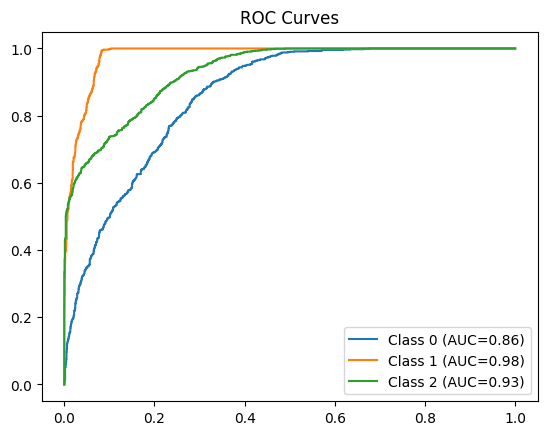

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_scores = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        y_scores.extend(probs)

y_scores = np.array(y_scores)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_scores[:,i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr,tpr):.2f})")

plt.legend()
plt.title("ROC Curves")
plt.show()

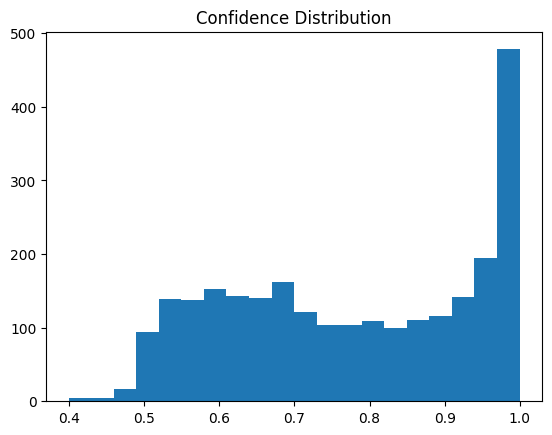

In [ ]:
confidences = []

with torch.no_grad():
    for x,y in test_loader:
        out = model(x.to(device))
        prob = torch.softmax(out,1)
        conf,_ = prob.max(1)
        confidences.extend(conf.cpu().numpy())

plt.hist(confidences, bins=20)
plt.title("Confidence Distribution")
plt.show()

In [ ]:
# ================================
# 🧪 FULL TEST PIPELINE
# ================================
def test_single_image(image_path, true_label=None):
    class_names = test_loader.dataset.classes  # ✅ FIX: use dataset ordering, not hardcoded list

    # 🔹 Load image
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 🔹 Resize
    resized = cv2.resize(gray, (224,224))

    # 🔹 CLAHE
    clahe = cv2.createCLAHE(2.0,(8,8)).apply(resized)

    # 🔹 Normalize
    norm = clahe.astype(np.float32)/255.0

    # 🔹 Stack channels
    input_img = np.stack([norm]*3, axis=0)
    input_tensor = torch.tensor(input_img).unsqueeze(0).to(device)

    # 🔹 Prediction
    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        prob = torch.softmax(out,1)
        conf, pred = prob.max(1)

    pred_class = class_names[pred.item()]
    confidence = conf.item()

    # 🔹 Grad-CAM
    cam = GradCAM(model)
    heatmap = cam.generate(input_tensor)

    heatmap_resized = cv2.resize(heatmap, (224,224))

    # 🔹 Plot EVERYTHING
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original")

    plt.subplot(1,4,2)
    plt.imshow(clahe, cmap='gray')
    plt.title("CLAHE")

    plt.subplot(1,4,3)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Grad-CAM")

    plt.subplot(1,4,4)
    plt.imshow(gray, cmap='gray')
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
    plt.title("Overlay")

    plt.show()

    # 🔹 Print results
    print("Prediction:", pred_class)
    print("Confidence:", confidence)

    if true_label is not None:
        print("Actual:", true_label)
        print("Correct:", pred_class == true_label)

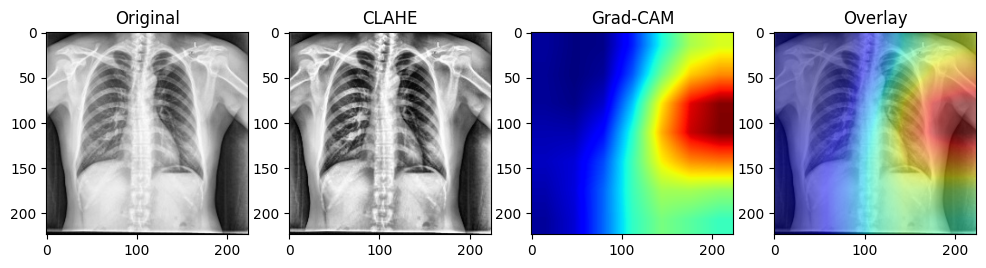

Prediction: tuberculosis
Confidence: 0.8936008214950562
Actual: tuberculosis
Correct: True


In [ ]:
test_single_image(f"{SAVE_PATH}/test/tuberculosis/tuberculosis-319.jpg", true_label="tuberculosis")

In [ ]:
# ================================
# 🚀 IMPORTS
# ================================
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm

# ================================
# ⚡ DEVICE
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# 📦 DATASET (UPDATED PREPROCESSING)
# ================================
class ImprovedDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx], cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError("Broken image")

        img = cv2.resize(img, (224,224))

        # 🔥 CLAHE
        clahe = cv2.createCLAHE(2.0,(8,8)).apply(img)

        # 🔥 EDGE DETECTION (KEY IMPROVEMENT)
        edges = cv2.Canny(clahe, 100, 200)

        # 🔥 COMBINE FEATURES
        combined = 0.7 * clahe + 0.3 * edges
        combined = combined.astype(np.float32) / 255.0

        # 3 channels
        combined = np.stack([combined]*3, axis=0)
        combined = np.ascontiguousarray(combined)

        return torch.from_numpy(combined), self.labels[idx]

# ================================
# 📦 DATA LOADERS
# ================================
train_loader = DataLoader(ImprovedDataset(SAVE_PATH + "/train"), batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(ImprovedDataset(SAVE_PATH + "/val"), batch_size=32, num_workers=0)

# ================================
# 🔥 FOCAL LOSS (KEY FIX)
# ================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        loss = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()

# ================================
# 🔥 CLASS WEIGHTS (BOOST TB)
# ================================
weights = torch.tensor([1.2, 1.5, 1.2]).to(device)

criterion = FocalLoss(alpha=weights)

# ================================
# 🤖 MODEL (STRONGER FINE-TUNING)
# ================================
model = models.mobilenet_v2(pretrained=True)

# Freeze all
for param in model.parameters():
    param.requires_grad = False

# 🔥 Unfreeze last 2 blocks
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Classifier
model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)

model = model.to(device)

# ================================
# ⚙️ OPTIMIZER
# ================================
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

# ================================
# 📈 TRAINING
# ================================
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # TRAIN
    model.train()
    train_loss = 0

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Train Loss:", train_loss/len(train_loader))

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            val_loss += criterion(model(x),y).item()

    print("Val Loss:", val_loss/len(val_loader))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



===== Epoch 1/3 =====


100%|██████████| 640/640 [01:11<00:00,  9.00it/s]


Train Loss: 0.3987226478056982
Val Loss: 0.2521021549589932

===== Epoch 2/3 =====


100%|██████████| 640/640 [01:10<00:00,  9.08it/s]


Train Loss: 0.25382277824683114
Val Loss: 0.21865361994132398

===== Epoch 3/3 =====


100%|██████████| 640/640 [01:10<00:00,  9.02it/s]


Train Loss: 0.22619252800941467
Val Loss: 0.19719779957085848


In [ ]:
class FinalDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]   # ✅ FIXED HERE

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Broken image: {path}")

        # 🔥 CENTER CROP (IMPORTANT)
        h, w = img.shape
        img = img[int(0.1*h):int(0.9*h), int(0.1*w):int(0.9*w)]

        # Resize
        img = cv2.resize(img, (224,224))

        # CLAHE
        img = cv2.createCLAHE(2.0,(8,8)).apply(img)

        # Normalize
        img = img.astype(np.float32) / 255.0
        img = (img - img.mean()) / (img.std() + 1e-5)

        # 3 channels
        img = np.stack([img]*3, axis=0)
        img = np.ascontiguousarray(img)

        return torch.from_numpy(img), self.labels[idx]

In [ ]:
import os, cv2, torch
import numpy as np
from torch.utils.data import Dataset

class FinalDataset(Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root, c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder, f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Broken image: {path}")

        # 🔥 CENTER CROP (focus on lungs)
        h, w = img.shape
        img = img[int(0.1*h):int(0.9*h), int(0.1*w):int(0.9*w)]

        img = cv2.resize(img, (224,224))

        # 🔥 CLAHE
        img = cv2.createCLAHE(2.0,(8,8)).apply(img)

        # 🔥 NORMALIZE
        img = img.astype(np.float32) / 255.0
        img = (img - img.mean()) / (img.std() + 1e-5)

        img = np.stack([img]*3, axis=0)
        img = np.ascontiguousarray(img)

        return torch.from_numpy(img), self.labels[idx]

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(FinalDataset(SAVE_PATH + "/train"), batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(FinalDataset(SAVE_PATH + "/val"), batch_size=32, num_workers=0)
test_loader  = DataLoader(FinalDataset(BASE_PATH + "/test"), batch_size=32, num_workers=0)

In [ ]:
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [ ]:
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(pretrained=True)

# Freeze all
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last layers
for p in model.features[-2:].parameters():
    p.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 3)
)

model = model.to(device)

In [ ]:
weights = torch.tensor([1.2, 1.5, 1.2]).to(device)  # TB focus
criterion = FocalLoss(alpha=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [ ]:
from tqdm import tqdm

EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    model.train()
    train_loss = 0

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Train Loss:", train_loss/len(train_loader))

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            val_loss += criterion(model(x),y).item()

    print("Val Loss:", val_loss/len(val_loader))


===== Epoch 1/3 =====


100%|██████████| 640/640 [01:00<00:00, 10.65it/s]


Train Loss: 0.5524661654606462
Val Loss: 0.3601887982338667

===== Epoch 2/3 =====


100%|██████████| 640/640 [01:00<00:00, 10.59it/s]


Train Loss: 0.36129315816797314
Val Loss: 0.320325796213001

===== Epoch 3/3 =====


100%|██████████| 640/640 [00:59<00:00, 10.74it/s]


Train Loss: 0.33288319371640684
Val Loss: 0.3042633653618395


In [ ]:
# ================================
# 🔥 GRAD-CAM  (ResNet18 – matches Cell 72 model)
# ================================
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.grad = None
        self.act  = None

        def f_hook(m, i, o):
            self.act = o

        # ✅ FIX: register_full_backward_hook (not deprecated register_backward_hook)
        def b_hook(m, gi, go):
            self.grad = go[0]

        # model.layer4 is correct for ResNet18
        self.model.layer4.register_forward_hook(f_hook)
        self.model.layer4.register_full_backward_hook(b_hook)

    def generate(self, x):
        self.model.eval()
        out = self.model(x)
        pred = out.argmax()

        self.model.zero_grad()
        out[0, pred].backward()

        weights = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.act).sum(dim=1)

        cam = cam.squeeze().cpu().detach().numpy()

        # ✅ FIX: ReLU before normalize – removes negative noise
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Sharpen then smooth
        cam = cam ** 1.5
        cam = cv2.GaussianBlur(cam, (5, 5), 0)

        return cam


In [ ]:
def test_single_image(path, true_label=None):
    class_names = test_loader.dataset.classes  # ✅ FIX: derive from loader, not hardcoded

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # same preprocessing
    h,w = img.shape
    img_crop = img[int(0.1*h):int(0.9*h), int(0.1*w):int(0.9*w)]
    img_resized = cv2.resize(img_crop,(224,224))
    img_clahe = cv2.createCLAHE(2.0,(8,8)).apply(img_resized)

    img_norm = img_clahe.astype(np.float32)/255.0
    img_norm = (img_norm - img_norm.mean())/(img_norm.std()+1e-5)

    tensor = torch.tensor(np.stack([img_norm]*3)).unsqueeze(0).to(device)

    # prediction
    model.eval()
    with torch.no_grad():
        out = model(tensor)
        prob = torch.softmax(out,1)
        conf,pred = prob.max(1)

    # gradcam
    cam = GradCAM(model)
    heatmap = cam.generate(tensor)
    heatmap = cv2.resize(heatmap,(224,224))

    # plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1); plt.imshow(img, cmap='gray'); plt.title("Original")
    plt.subplot(1,4,2); plt.imshow(img_clahe, cmap='gray'); plt.title("CLAHE")
    plt.subplot(1,4,3); plt.imshow(heatmap, cmap='jet'); plt.title("GradCAM")
    plt.subplot(1,4,4)
    plt.imshow(img_resized, cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=0.6)
    plt.title("Overlay")

    plt.show()

    pred_class = class_names[pred.item()]
    confidence = conf.item()

    if confidence < 0.7:
        pred_class = "REVIEW"

    print("Prediction:", pred_class)
    print("Confidence:", confidence)

    if true_label:
        print("Actual:", true_label)
        print("Correct:", pred_class == true_label)

In [ ]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.grad = None
        self.act = None

        def forward_hook(module, input, output):
            self.act = output

        def backward_hook(module, grad_in, grad_out):
            self.grad = grad_out[0]

        # ✅ CORRECT LAYER FOR RESNET
        # Fixed: Use self.model.layer4 instead of global model.layer4
        self.model.layer4.register_forward_hook(forward_hook)
        self.model.layer4.register_backward_hook(backward_hook)

    def generate(self, x):
        out = self.model(x)
        pred = out.argmax()

        self.model.zero_grad()
        out[0, pred].backward()

        weights = self.grad.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.act).sum(dim=1)

        cam = cam.squeeze().cpu().detach().numpy()

        # sharpen
        cam = np.maximum(cam, 0)
        cam = cam ** 2
        cam = cam / (cam.max() + 1e-8)

        return cam

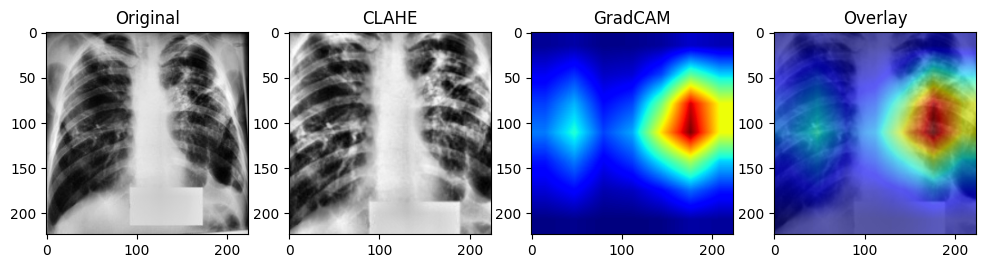

Prediction: tuberculosis
Confidence: 0.9956722259521484
Actual: tuberculosis
Correct: True


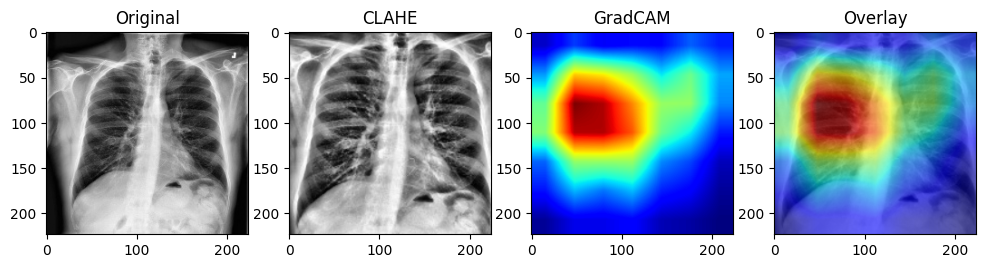

Prediction: REVIEW
Confidence: 0.5862562656402588
Actual: normal
Correct: False


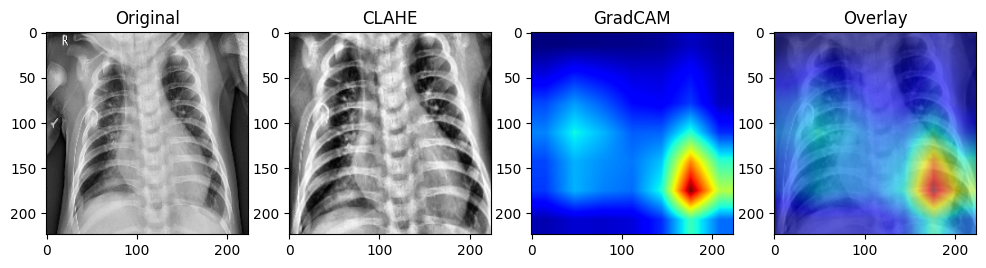

Prediction: pneumonia
Confidence: 0.9811278581619263
Actual: pneumonia
Correct: True


In [ ]:
test_single_image(f"{SAVE_PATH}/test/tuberculosis/tuberculosis-650.jpg", true_label="tuberculosis")
test_single_image(f"{SAVE_PATH}/test/normal/normal-11.jpg", true_label="normal")
test_single_image(f"{SAVE_PATH}/test/pneumonia/pneumonia-101.jpg", true_label="pneumonia")

In [ ]:
# ================================
# 🚀 IMPORTS
# ================================
import os, cv2, torch
import numpy as np
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# 📦 DATASET (FINAL CLEAN VERSION)
# ================================
class FinalDataset(Dataset):
    def __init__(self, root):
        self.paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root))
        self.map = {c:i for i,c in enumerate(self.classes)}

        for c in self.classes:
            folder = os.path.join(root,c)
            for f in os.listdir(folder):
                self.paths.append(os.path.join(folder,f))
                self.labels.append(self.map[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Broken image: {path}")

        # 🔥 center crop (lung focus)
        h,w = img.shape
        img = img[int(0.1*h):int(0.9*h), int(0.1*w):int(0.9*w)]

        img = cv2.resize(img,(224,224))

        # 🔥 stronger CLAHE (helps TB)
        img = cv2.createCLAHE(3.0,(8,8)).apply(img)

        # normalize
        img = img.astype(np.float32)/255.0
        img = (img - img.mean())/(img.std()+1e-5)

        img = np.stack([img]*3, axis=0)
        img = np.ascontiguousarray(img)

        return torch.from_numpy(img), self.labels[idx]

# ================================
# 📦 LOADERS
# ================================
train_loader = DataLoader(FinalDataset(SAVE_PATH+"/train"), batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(FinalDataset(SAVE_PATH+"/val"), batch_size=32, num_workers=0)
test_loader  = DataLoader(FinalDataset(BASE_PATH+"/test"), batch_size=32, num_workers=0)

# ================================
# 🔥 FOCAL LOSS
# ================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce)
        return ((1 - pt)**self.gamma * ce).mean()

# ================================
# 🔥 CONFUSION-AWARE LOSS (KEY FIX)
# ================================
class ConfusionLoss(nn.Module):
    def __init__(self, base_loss, penalty=2.0):
        super().__init__()
        self.base_loss = base_loss
        self.penalty = penalty

    def forward(self, outputs, targets):
        loss = self.base_loss(outputs, targets)
        preds = torch.argmax(outputs, dim=1)

        mask = ((targets==1)&(preds==2)) | ((targets==2)&(preds==1))

        if mask.any():
            loss += self.penalty * mask.float().mean()

        return loss

# class weights (boost TB)
weights = torch.tensor([1.2,1.5,1.2]).to(device)

base_loss = FocalLoss(alpha=weights)
criterion = ConfusionLoss(base_loss, penalty=2.0)

# ================================
# 🤖 MODEL (UPGRADED)
# ================================
model = models.resnet18(pretrained=True)

# freeze
for p in model.parameters():
    p.requires_grad = False

# unfreeze last layers
for p in model.layer4.parameters():
    p.requires_grad = True

# classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features,128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128,3)
)

model = model.to(device)

# ================================
# ⚙️ OPTIMIZER
# ================================
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

# ================================
# 📈 TRAINING
# ================================
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} ====")

    model.train()
    train_loss = 0

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        out = model(x)
        loss = criterion(out,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Train Loss:", train_loss/len(train_loader))

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            val_loss += criterion(model(x),y).item()

    print("Val Loss:", val_loss/len(val_loader))

# ================================
# 🔥 FINAL TEST FUNCTION
# ================================
def test_single_image(path, true_label=None):
    class_names = test_loader.dataset.classes  # ✅ FIX: derive from loader

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    h,w = img.shape
    crop = img[int(0.1*h):int(0.9*h), int(0.1*w):int(0.9*w)]
    resized = cv2.resize(crop,(224,224))
    clahe = cv2.createCLAHE(3.0,(8,8)).apply(resized)

    norm = clahe.astype(np.float32)/255.0
    norm = (norm - norm.mean())/(norm.std()+1e-5)

    tensor = torch.tensor(np.stack([norm]*3)).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(tensor)
        prob = torch.softmax(out,1)
        conf,pred = prob.max(1)

    pred_class = class_names[pred.item()]
    confidence = conf.item()

    if confidence < 0.75:
        pred_class = "REVIEW"

    print("Prediction:", pred_class)
    print("Confidence:", confidence)

    if true_label:
        print("Actual:", true_label)
        print("Correct:", pred_class == true_label)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



===== Epoch 1/3 ====


100%|██████████| 640/640 [01:01<00:00, 10.44it/s]


Train Loss: 0.523142971121706
Val Loss: 0.32907854551449417

===== Epoch 2/3 ====


100%|██████████| 640/640 [01:02<00:00, 10.25it/s]


Train Loss: 0.3355912745231763
Val Loss: 0.3056545777246356

===== Epoch 3/3 ====


100%|██████████| 640/640 [01:01<00:00, 10.49it/s]


Train Loss: 0.3031671289470978
Val Loss: 0.294559346139431
